In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
x_0 = 0
v_0 = 1
k = 1
m = 1
dt = 0.1
N_t = 1000

t_arr = np.arange(0, N_t * dt, dt)
x_arr = np.zeros(N_t)
v_arr = np.zeros(N_t)

x_arr[0] = x_0
v_arr[0] = v_0

In [9]:
def energy(x, v):
    return 0.5 * k * x ** 2 + 0.5 * m * v ** 2

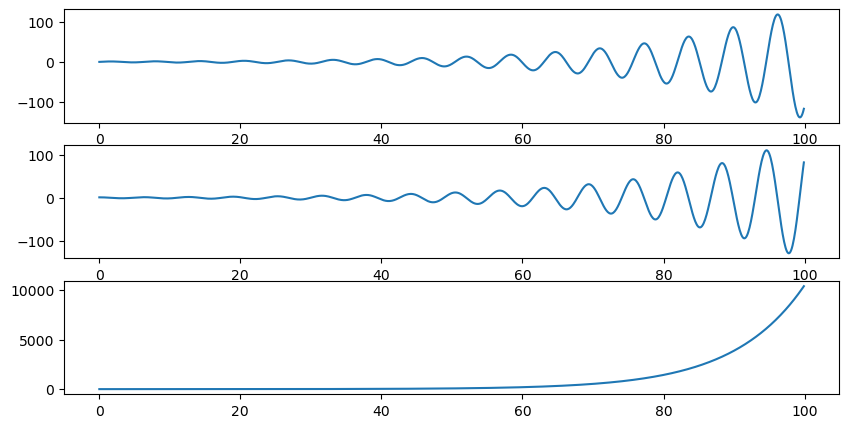

In [12]:
# numerical heating
for i in range(1, N_t):
    x_arr[i] = x_arr[i-1] + v_arr[i-1] * dt
    v_arr[i] = v_arr[i-1] - k/m * x_arr[i - 1] * dt

fig, axs = plt.subplots(3, 1, figsize=(10, 5))
axs[0].plot(t_arr, x_arr)
axs[1].plot(t_arr, v_arr)
axs[2].plot(t_arr, energy(x_arr, v_arr))

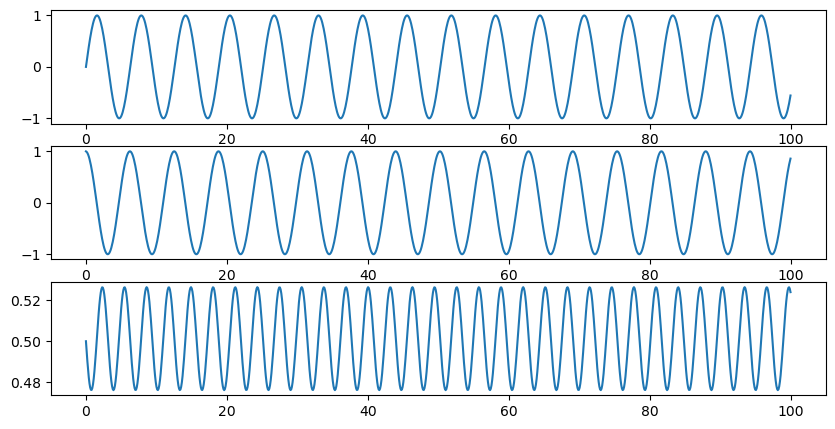

In [13]:
# conserved energy / equilibrium
for i in range(1, N_t):
    x_arr[i] = x_arr[i-1] + v_arr[i-1] * dt
    v_arr[i] = v_arr[i-1] - k/m * x_arr[i] * dt

fig, axs = plt.subplots(3, 1, figsize=(10, 5))
axs[0].plot(t_arr, x_arr)
axs[1].plot(t_arr, v_arr)
axs[2].plot(t_arr, energy(x_arr, v_arr))

system of equations for the first case:


$x_{i + 1} = x_i + v_i\Delta t$

$v_{i + 1} = v_i - \frac{k}{m} x_{i}$



in matrix form (x_i+1, v_i+1): rotation matrix ((1, \Delta t), (-k/m \Delta t, 1)) times (x_i, v_i)

determinant of the rotation matrix: $1 + \frac{k}{m} \Delta t^2$



in the second case, 

$v_{i + 1} = v_i - \frac{k}{m} x_{i+1} \Delta t = v_i - \frac{k}{m} (x_i + v_i\Delta t) \Delta t$

and the determinant of the rotation matrix here becomes $1 - \frac{k}{m} \Delta t^2 - (- \frac{k}{m} \Delta t^2) = 1$
(sympletic integrators; preserves the Hamiltonian of the system)